# 12 · 패턴: CI 스위퍼 (고치기 전에 분류하라)

**패턴:** CI 스위퍼(CI sweeper).

> "불안정(flake)이면 — 전에 본 적이 있고 간헐적으로만 실패한다면 — 감시 목록에 올리고 자동 수정하지 않는다. 조치 가능한 실패라면 워크트리를 열고 구현자가 수정안을 작성한다." 안티패턴: 실패의 정체가 불안정인데 애플리케이션 코드를 바꾸는 것. 인프라 문제를 가리고 무작위 diff 를 쌓는다.

**문제 설정** — 빨간 빌드는 진짜 회귀일 수도 있고 불안정 테스트(flaky test)일 수도 있다. 두 가지는 화면에서 똑같이 빨갛다. 전부 고치려 드는 스위퍼는 불안정 쪽에 시도와 돈을 태우고, 최악의 경우 증상을 덮는 방식으로 그것을 "고쳐" 버린다. 옳은 수는 먼저 분류하는 것이다 — **진짜 실패는 결정적으로 실패하고, 불안정은 코드를 한 줄도 고치지 않아도 재실행에서 통과한다.**

**측정 대상** — 실제로 실패하는 테스트 집합(절반은 진짜 버그, 절반은 구성상 불안정)에서 재실행 기반 불안정 분류기의 정확도. 그리고 "전부 고친다" 는 순진한 스위퍼가 "먼저 분류한다" 는 스위퍼에 비해 낭비하는 수정 시도와 토큰의 양.

**이 노트북이 코스에서 차지하는 자리** — 01번은 "루프를 검증 가능한 신호에 연결하라" 였다. 여기서는 그 문장을 한 칸 앞으로 당긴다 — **연결하기 전에, 그 신호가 진짜인지부터 판정하라.** 불안정 테스트는 신호처럼 생긴 잡음이고, 잡음에 연결된 루프는 성실하게 잘못된 방향으로 내려간다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

======================================== CI 스위퍼: 불안정이냐 진짜냐 =========================================


*실패를 먼저 분류한다: 진짜 회귀는 고치고, 불안정은 격리하고, 인프라는 사람에게 넘긴다*

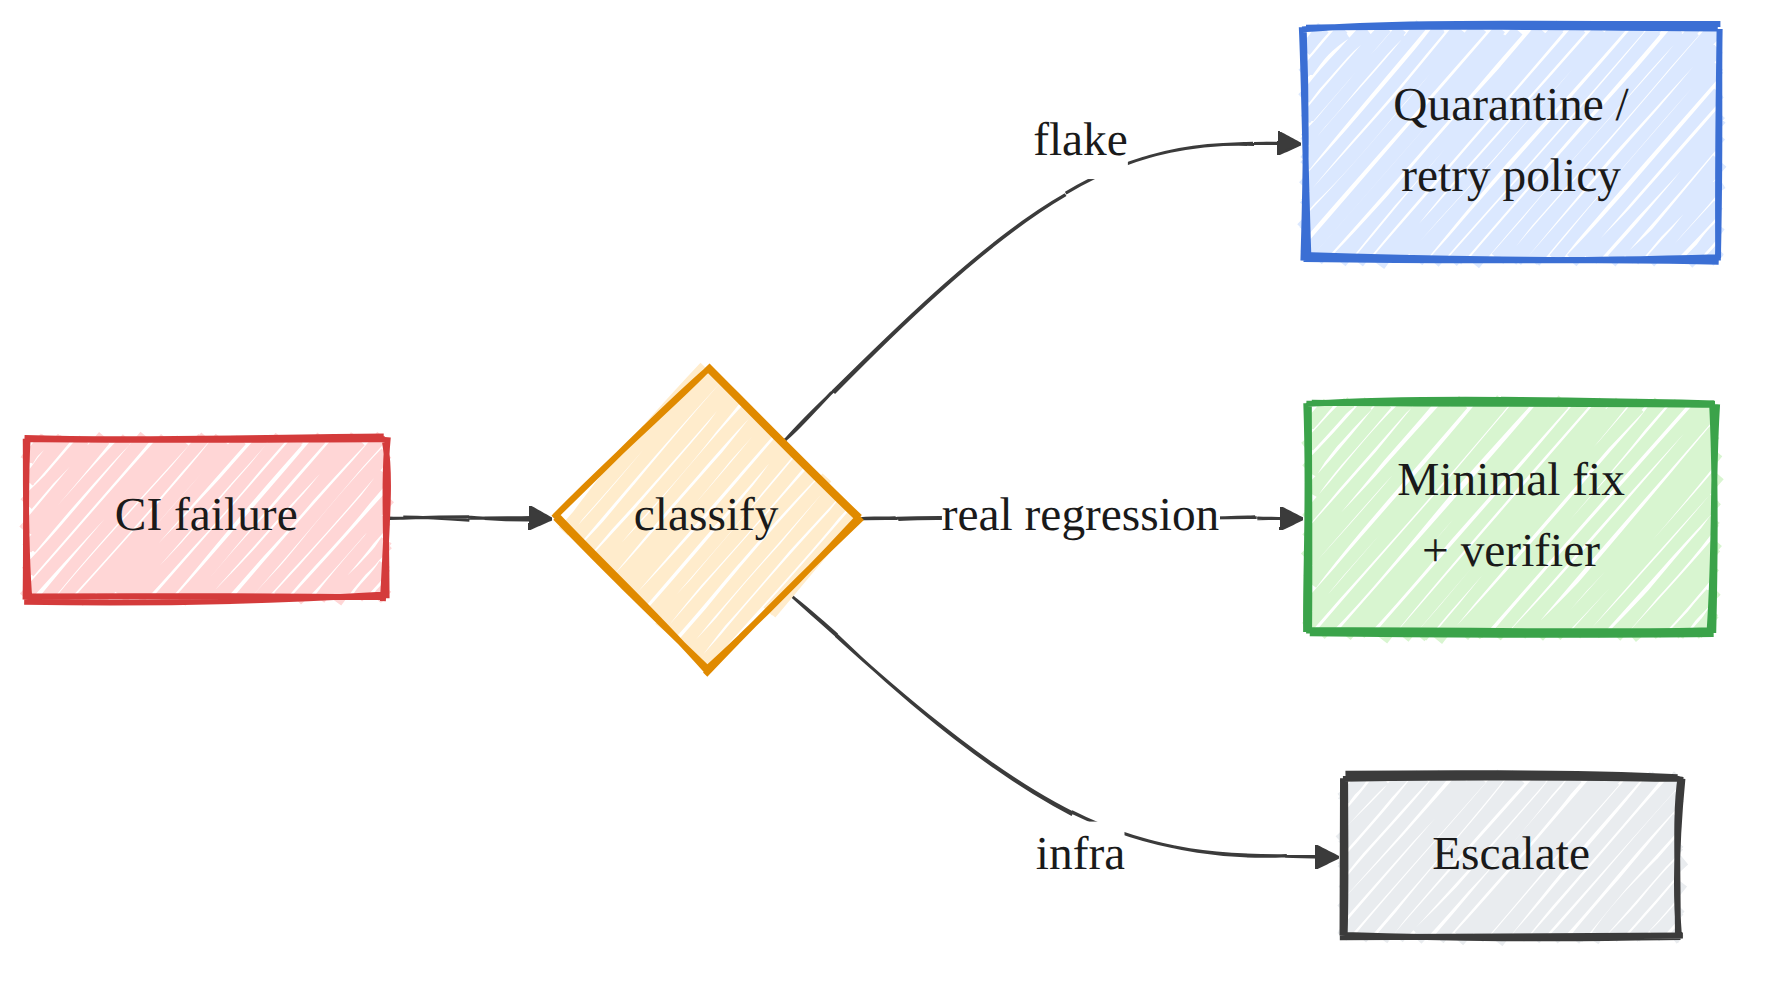

  실패한 테스트 수:                 20
  (정답) 진짜 / 불안정:             10 / 10


In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, plotting, runlog, runtime

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API).
# 이 노트북의 분류기 자체는 모델을 전혀 부르지 않지만, 뒤쪽 12번 셀의 수정 루프가
# 백엔드를 쓴다. 여기서 미리 판별해 두면 어느 엔진의 수치인지가 기록에 남는다.
rt = runtime.bootstrap()

show.head("CI 스위퍼: 불안정이냐 진짜냐")
show.diagram("ci_sweeper", "실패를 먼저 분류한다: 진짜 회귀는 고치고, 불안정은 격리하고, 인프라는 사람에게 넘긴다")

# ── 작업대 구성: 실패하는 테스트 20건을 손으로 만든다 ─────────────────
# 실제 CI 로그를 쓰지 않는 이유는 정답 라벨이 필요하기 때문이다. 분류기의
# 정확도를 재려면 각 실패의 진짜 정체를 우리가 알고 있어야 한다.
N_EACH = 10
real_tests = []
for i in range(N_EACH):
    # 진짜 버그: 함수가 틀린 값을 돌려주므로 테스트는 매 실행에서 실패한다.
    # 결정성이 핵심이다. 이 결정성이 뒤에서 "real" 판정의 근거가 된다.
    code = f"def f(x):\n    return x - {i + 1}\nassert f(10) == {10 + i + 1}, 'regression'\n"
    real_tests.append({"id": f"real_{i}", "code": code, "true": "real"})
flake_tests = []
for i in range(N_EACH):
    # 불안정: 난수에 의존할 뿐 코드 결함은 없다. 실행당 1/4 확률로 통과한다.
    # ⚠️ 함정: 이 테스트를 "고칠" diff 는 존재하지 않는다. 그런데도 구현자에게
    #    넘기면 구현자는 반드시 무언가를 고쳐서 내놓는다. 그 diff 가 문제다.
    code = "import random\nassert random.randint(0, 3) == 0, 'flaky timing/random'\n"
    flake_tests.append({"id": f"flake_{i}", "code": code, "true": "flake"})
tests = real_tests + flake_tests
show.kv("실패한 테스트 수", len(tests))
show.kv("(정답) 진짜 / 불안정", f"{N_EACH} / {N_EACH}")

## 재실행 기반 분류기

실패한 테스트를 각각 새 프로세스에서 몇 번 다시 돌린다. 진짜 실패는 매번 똑같이 실패한다. 불안정은 코드를 한 줄도 바꾸지 않았는데 결과가 갈린다. **그 불일치가 불안정의 정석적인 신호다.**


In [2]:
def classify(code, runs=5):
    """같은 코드를 새 프로세스에서 runs 회 돌려 결과의 일관성으로 판정한다.

    분류의 근거는 코드를 읽는 것이 아니라 실행 결과의 분산이다. 모델을 전혀
    부르지 않으므로 이 분류기의 토큰 비용은 0 이다. 뒤의 경제성 논의가
    성립하는 근거가 여기 있다.
    """
    outcomes = []
    for _ in range(runs):
        # timeout=5 는 무한 루프에 걸린 테스트가 분류기 전체를 멈추지 못하게 한다.
        # 신뢰할 수 없는 코드를 실제로 실행하는 이상 상한은 선택 사항이 아니다.
        r = ev.run_program(code, timeout=5)
        outcomes.append(r.ok)  # 이번 실행에서 테스트가 통과했으면 True
    if all(not o for o in outcomes):
        return "real"          # 매번 실패 → 결정적 실패
    if any(outcomes) and not all(outcomes):
        return "flake"         # 결과가 갈린다 → 불안정
    return "passing"           # 매번 통과 → 애초에 실패 상태가 아니다


# ⚠️ 함정: runs=5 는 공짜로 정해진 값이 아니라 정확도와 재실행 예산의 교환점이다.
#    통과 확률이 낮은 불안정일수록 더 많은 재실행이 필요하다. 이 값을 그대로
#    실제 CI 에 옮기면 드물게 터지는 불안정을 진짜 실패로 오분류하게 된다.
preds = []
for t in tests:
    p = classify(t["code"])
    preds.append(p)
    print(f"  {t['id']:<9} true={t['true']:<6} predicted={p}")

correct = sum(1 for t, p in zip(tests, preds) if p == t["true"])
acc = correct / len(tests)
show.head("분류기 정확도")
show.metric("불안정 vs 진짜 판별 정확도", acc)

  real_0    true=real   predicted=real
  real_1    true=real   predicted=real
  real_2    true=real   predicted=real
  real_3    true=real   predicted=real
  real_4    true=real   predicted=real
  real_5    true=real   predicted=real
  real_6    true=real   predicted=real
  real_7    true=real   predicted=real
  real_8    true=real   predicted=real
  real_9    true=real   predicted=real
  flake_0   true=flake  predicted=flake
  flake_1   true=flake  predicted=real
  flake_2   true=flake  predicted=flake
  flake_3   true=flake  predicted=flake
  flake_4   true=flake  predicted=flake
  flake_5   true=flake  predicted=flake
  flake_6   true=flake  predicted=flake
  flake_7   true=flake  predicted=flake
  flake_8   true=flake  predicted=flake
  flake_9   true=flake  predicted=flake

============================================= 분류기 정확도 ==============================================
  불안정 vs 진짜 판별 정확도                 0.9500


## 두 개의 스위퍼

- **순진한 방식** — 실패한 테스트마다 수정 시도를 건다. 시도 한 번은 구현자와 검증기의 실행 한 세트이고, 약 200,000 토큰이 든다.
- **분류 우선 방식** — 진짜 회귀에만 수정 시도를 건다. 불안정은 격리한다(티켓만 남기고 코드는 건드리지 않는다). 인프라 문제였다면 사람에게 넘긴다.


In [3]:
# ── 두 스위퍼의 지출을 계산한다 ───────────────────────────────────
# 수정 시도 한 번의 단가. 구현자 생성 + 검증기 실행 + 재시도까지 묶은
# 보수적인 예산치다. 이 값 하나가 아래 절감액 전체의 축척을 정한다.
TOKENS_PER_FIX = 200_000

naive_fix_attempts = len(tests)                                # 전부 고치려 든다
classify_fix_attempts = sum(1 for p in preds if p == "real")   # 진짜만 고친다

# ⚠️ 함정: 낭비는 예측 라벨이 아니라 정답 라벨로 센다. 분류기가 틀렸을 때
#    "분류기 기준으로는 낭비가 없었다" 는 자기채점이 되기 때문이다. 계측기를
#    피측정 대상의 의견으로 채점하면 03번이 잰 오수용이 그대로 재현된다.
wasted_naive = sum(1 for t in tests if t["true"] == "flake")

show.metric("순진한 스위퍼의 수정 시도", naive_fix_attempts)
show.metric("분류 우선 스위퍼의 수정 시도", classify_fix_attempts)
show.metric("순진한 방식이 불안정에 버린 시도", wasted_naive)
show.metric("순진한 방식이 불안정에 태운 토큰", wasted_naive * TOKENS_PER_FIX)
show.metric("분류 우선이 아낀 토큰", wasted_naive * TOKENS_PER_FIX)

  순진한 스위퍼의 수정 시도                   20
  분류 우선 스위퍼의 수정 시도                 11
  순진한 방식이 불안정에 버린 시도               10
  순진한 방식이 불안정에 태운 토큰               2000000
  분류 우선이 아낀 토큰                     2000000


## 진짜 실패는 정말로 고쳐진다 (루프가 자기 예산값을 한다)

분류 우선 스위퍼가 남긴 예산을 제대로 쓰는지 확인하려면, 그 예산이 흘러가는 쪽을 직접 돌려 봐야 한다. 분류 우선이 구현자에게 넘기는 종류의 대표적인 진짜 회귀 하나를 골라, 01번의 자기 개선 루프를 그대로 돌린다.


In [4]:
from common.llm import LLM  # noqa: E402
from common import agents, loops  # noqa: E402

llm = LLM()

# 분류 우선 스위퍼가 구현자에게 라우팅하는 항목의 대표 사례를 하나 만든다.
# 위 real_10 계열과 같은 종류의 결정적 회귀다.
real_problem = type("P", (), {
    "prompt": "Implement `def f(x): return x - 11` is wrong; it should return x + 11. Provide the corrected function f.",
    "kind": "asserts", "entry_point": "f",
    "tests": "assert f(10) == 21\nassert f(0) == 11\n",
})()

# ⚠️ 함정: max_attempts=2 라는 상한이 여기에도 붙어 있다는 점이 중요하다.
#    분류기는 "고칠 수 없는 것" 을 걸러 주지만 "고치기 어려운 것" 까지
#    걸러 주지는 못한다. 01번의 시도 상한은 분류 뒤에도 여전히 필요하다.
fix = loops.self_refine(llm, real_problem, max_attempts=2, use_feedback=True)
show.kv("루프가 진짜 회귀를 고쳤는가", fix["solved"])

  루프가 진짜 회귀를 고쳤는가:           True


## 그래프

두 장의 막대그래프가 같은 이야기를 단위만 바꿔 보여 준다. 하나는 시도 횟수로, 하나는 토큰으로.


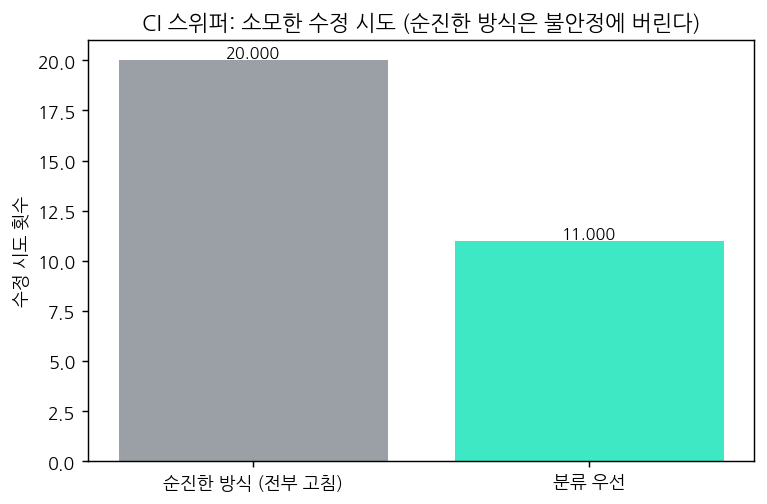

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/12_wasted_attempts.png


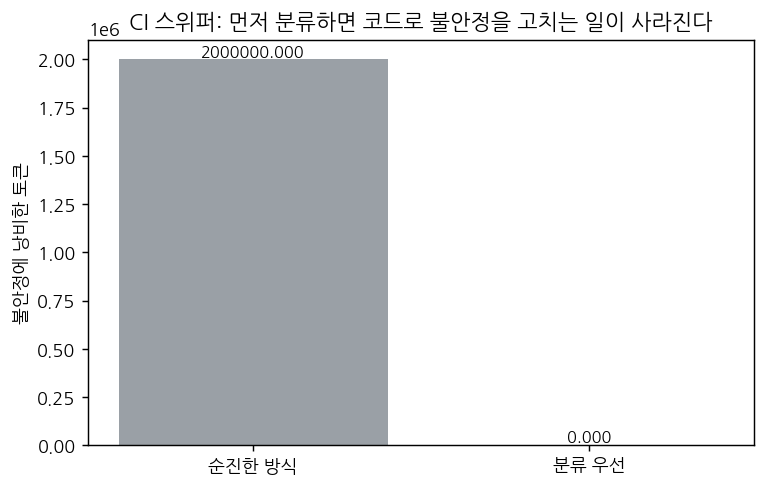

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/12_tokens_wasted.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/12_ci_sweeper.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (ci-sweeper: fix-proposed, ~106 tokens)


{'run_id': '2026-08-19T07:33:35Z',
 'pattern': 'ci-sweeper',
 'duration_s': 0.0,
 'items_found': 20,
 'actions_taken': 11,
 'escalations': 0,
 'tokens_estimate': 106,
 'outcome': 'fix-proposed'}

In [5]:
plotting.ab_bar("12_wasted_attempts", ["순진한 방식 (전부 고침)", "분류 우선"],
                [naive_fix_attempts, classify_fix_attempts], "수정 시도 횟수",
                "CI 스위퍼: 소모한 수정 시도 (순진한 방식은 불안정에 버린다)")
plotting.ab_bar("12_tokens_wasted", ["순진한 방식", "분류 우선"],
                [wasted_naive * TOKENS_PER_FIX, 0], "불안정에 낭비한 토큰",
                "CI 스위퍼: 먼저 분류하면 코드로 불안정을 고치는 일이 사라진다")

# 분류기 정확도와 절감액을 함께 남긴다. 08번이 비용 모델을 재구성할 때
# 둘이 같이 있어야 한다. 절감액만 있으면 정확도가 떨어졌을 때의 감쇠를 못 센다.
runlog.save_metrics("12_ci_sweeper", {"notebook": "12_ci_sweeper", "n": len(tests),
                                       "provider": llm.provider,   # 한국어판 추가: 어느 백엔드의 수치인지 기록
                                       "model": llm.model,
                                       "classifier_accuracy": acc, "naive_fix_attempts": naive_fix_attempts,
                                       "classify_fix_attempts": classify_fix_attempts,
                                       "tokens_saved": wasted_naive * TOKENS_PER_FIX, "real_fixed": fix["solved"]})
# escalations=0 인 이유: 이 구성에는 인프라 실패가 섞여 있지 않다. 실제 스위퍼라면
# 세 번째 갈래(인프라)가 여기에 잡혀야 하고, 그 값이 계속 0 이면 분류기가
# 인프라를 다른 라벨로 흡수하고 있다는 뜻이므로 의심해야 한다.
runlog.log_run(pattern="ci-sweeper", duration_s=0, items_found=len(tests),
               actions_taken=classify_fix_attempts, escalations=0,
               tokens_estimate=llm.usage.total_tokens, outcome="fix-proposed")

## 이 실행이 실제로 보여 준 것


In [6]:
show.head("이 실행이 실제로 보여 준 것")
print(f"재실행 기반 분류기는 진짜 실패와 불안정을 {acc:.0%} 정확도로 갈랐다.")
print(f"'전부 고친다' 는 순진한 스위퍼라면 수정 시도 {naive_fix_attempts}건을 걸었을 것이고,")
print(f"그중 {wasted_naive}건을 불안정에 버렸을 것이다 (약 {wasted_naive * TOKENS_PER_FIX:,} 토큰). 증상을 덮는 수정의 위험은 덤이다.")
print(f"분류 우선은 수정 시도를 {classify_fix_attempts}건만 걸었고 (진짜 회귀들), 라우팅된 진짜 회귀를")
print(f"루프가 실제로 고쳤다: {fix['solved']}.")
print()
print("=> 고치기 전에 분류하라. 불안정의 신호는 재실행에서의 간헐성이지, 코드 변경이 아니다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
재실행 기반 분류기는 진짜 실패와 불안정을 95% 정확도로 갈랐다.
'전부 고친다' 는 순진한 스위퍼라면 수정 시도 20건을 걸었을 것이고,
그중 10건을 불안정에 버렸을 것이다 (약 2,000,000 토큰). 증상을 덮는 수정의 위험은 덤이다.
분류 우선은 수정 시도를 11건만 걸었고 (진짜 회귀들), 라우팅된 진짜 회귀를
루프가 실제로 고쳤다: True.

=> 고치기 전에 분류하라. 불안정의 신호는 재실행에서의 간헐성이지, 코드 변경이 아니다.
